In [1]:
import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")

# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")

El arbol tiene 933000 eventos.


In [2]:

# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_nSegments", "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays


In [3]:
# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")


El arbol tiene 933000 eventos.


In [4]:
from collections import defaultdict
import time

data = defaultdict(list)

max_eventos = 5000

start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    start_event = time.time()
    if i >= max_eventos:
        break  # Detener el bucle cuando se alcanzan max_eventos
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    end_event = time.time()
    if i%1000==0:
        print(f"Evento {i+1}: {end_event - start_event:.2f} segundos")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()
#tarda como 1 minuto

Evento 1: 0.05 segundos
Evento 1001: 0.00 segundos
Evento 2001: 0.00 segundos
Evento 3001: 0.00 segundos
Evento 4001: 0.00 segundos
Tiempo total: 3.50 segundos


In [5]:
# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())

# Guardar el DataFrame en un archivo CSV
# df.to_csv('data.csv', index=False)
# print('Data saved in data.csv')

#Ahora ya puedes trabajar con el df para generar las entradas/verdades de tu modelo de ML
#Siempre asegurate de preprocesar el df, rellenar los NaNs, normalizar los datos, etc.

#Recuerda que deberiamos filtrar los digis pertenecientes a la SL2 (no trabajamos en esa dimension)
#Lo mismo para los segmentos que no tienen hits en phi (son segmentos de la SL2 y tambien tenemos que cargarnoslos)
# Suerte! :)

Longitud de cada rama:
event_eventNumber: 5000
digi_nDigis: 5000
digi_wheel: 5000
digi_sector: 5000
digi_station: 5000
digi_superLayer: 5000
digi_layer: 5000
digi_wire: 5000
digi_time: 5000
seg_nSegments: 5000
seg_wheel: 5000
seg_sector: 5000
seg_station: 5000
seg_hasPhi: 5000
seg_hasZed: 5000
seg_posLoc_x: 5000
seg_posLoc_y: 5000
seg_posLoc_z: 5000
seg_dirLoc_x: 5000
seg_dirLoc_y: 5000
seg_dirLoc_z: 5000
seg_posLoc_x_SL1: 5000
seg_posLoc_x_SL3: 5000
seg_posLoc_x_midPlane: 5000
seg_posGlb_phi: 5000
seg_posGlb_eta: 5000
seg_dirGlb_phi: 5000
seg_dirGlb_eta: 5000
seg_phi_t0: 5000
seg_phi_vDrift: 5000
seg_phi_normChi2: 5000
seg_phi_nHits: 5000
seg_z_normChi2: 5000
seg_z_nHits: 5000
seg_phiHits_pos: 5000
seg_phiHits_posCh: 5000
seg_phiHits_posErr: 5000
seg_phiHits_side: 5000
seg_phiHits_wire: 5000
seg_phiHits_wirePos: 5000
seg_phiHits_layer: 5000
seg_phiHits_superLayer: 5000
seg_phiHits_time: 5000
seg_phiHits_timeCali: 5000

Vista previa del DataFrame:

Numero de hits por evento en 'seg_phi

In [6]:
from newGeo.dtGeometry import *
from itertools import chain
import logging

geometry_xml_path = "newGeo/DTGeometry.xml"

# Parse DT Geometry XML
print("\nParsing DT Geometry XML...")
df_geometry = parse_dtgeometry_xml(geometry_xml_path)

def create_wire_position_mapping(df_geometry):
    mapping = {}
    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_total = row['Channels_total']
        wireFirst = row['WirePositions_FirstWire']
        wireLast = row['WirePositions_LastWire']

        # Create Wire object to get positions
        wire_obj = Wire(wireFirst, wireLast, channels_total, row['Layer_Local_z'])
        # Map wire numbers to positions
        for wire_idx, x_pos in enumerate(wire_obj.positions):
            wire_number = wire_idx + 1  # Assuming wire numbers start from 1
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = x_pos
    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping, pos_none=False):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    none_keys = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is None:
            none_keys.append(key)
        x_positions.append(x_pos)
    df['digi_x_pos'] = x_positions
    if pos_none == True:
        print(f'Cantidad de keys sin posicion =  {len(none_keys)} \n Keys: \n {none_keys}')
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# Crear mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['digi_wheel', 'digi_sector', 'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_digis(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping, pos_none = True)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe(df, df_flattened, list_columns, ['digi_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
digi_wire_index = columns.index('digi_wire')
columns.insert(digi_wire_index + 1, columns.pop(columns.index('digi_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head(2)



Parsing DT Geometry XML...
Cantidad de keys sin posicion =  1130 
 Keys: 
 [(576880640, 3, 4, 49), (577536000, 3, 4, 49), (577011712, 3, 4, 49), (579141632, 1, 4, 60), (580026368, 2, 4, 57), (579731456, 1, 4, 60), (579731456, 3, 4, 60), (580157440, 1, 4, 60), (576749568, 3, 4, 49), (580026368, 3, 4, 60), (576061440, 3, 4, 49), (575275008, 2, 4, 57), (577273856, 1, 4, 49), (575963136, 1, 4, 49), (577798144, 1, 4, 49), (574914560, 2, 4, 57), (581042176, 1, 4, 60), (577536000, 3, 4, 49), (577667072, 3, 4, 49), (576061440, 1, 4, 49), (577404928, 1, 4, 49), (575471616, 1, 4, 49), (575832064, 3, 4, 49), (576094208, 3, 4, 49), (581337088, 1, 4, 60), (576225280, 1, 4, 49), (577404928, 1, 4, 49), (584155136, 3, 4, 72), (576847872, 2, 4, 57), (574914560, 3, 4, 49), (577863680, 2, 4, 57), (577142784, 1, 4, 49), (579764224, 2, 4, 57), (574914560, 1, 4, 49), (581042176, 1, 4, 60), (581566464, 1, 4, 60), (581566464, 3, 4, 60), (585662464, 3, 4, 72), (577536000, 1, 4, 49), (577273856, 1, 4, 49), (57

,event_eventNumber,digi_nDigis,digi_wheel,digi_sector,digi_station,digi_superLayer,digi_layer,digi_wire,digi_x_pos,digi_time,...,seg_phiHits_pos_count,seg_phiHits_posCh_count,seg_phiHits_posErr_count,seg_phiHits_side_count,seg_phiHits_wire_count,seg_phiHits_wirePos_count,seg_phiHits_layer_count,seg_phiHits_superLayer_count,seg_phiHits_time_count,seg_phiHits_timeCali_count
0,27005,23,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[28, 28, 27, 28, 10, 11, 10, 10, 26, 26, 25, 2...","[14.199997981250007, 12.099990387755085, 9.999...","[917.1875, 593.75, 780.46875, 774.21875, 850.0...",...,2,2,2,2,2,2,2,2,2,2
1,27004,131,"[2, 2, 2, 2, -2, -2, -2, -2, -2, -2, -2, -2, -...","[2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, ...","[1, 2, 3, 4, 1, 3, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[2, 2, 1, 2, 5, 4, 5, 5, 7, 7, 6, 6, 5, 5, 5, ...","[-95.00001190416667, -97.09998840816327, -99.1...","[523.4375, 549.21875, 722.65625, 865.625, 773....",...,15,15,15,15,15,15,15,15,15,15


In [7]:
# hacemos lo mismo para los segmentos
def add_chamber_rawId_to_segments(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['seg_wheel'], row['seg_station'], row['seg_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['seg_chamber_rawId'] = chamber_rawIds
    return df

def map_segments_wires_to_positions(df, wire_position_mapping, pos_none = False):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    none_keys = []
    for idx, row in df.iterrows():
        key = (row['seg_chamber_rawId'], row['seg_phiHits_superLayer'], row['seg_phiHits_layer'], row['seg_phiHits_wire'])  
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is None:
            none_keys.append(key)       
        x_positions.append(x_pos)
    df['seg_x_pos'] = x_positions
    if pos_none == True:
        print(f'Cantidad de keys sin posicion =  {len(none_keys)} \n Keys: \n {none_keys}')
    return df

def reconstruct_dataframe_seg(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    # Ajustar índice según las filas ya existentes en df_flattened
    df_flattened["original_index"] = df_original.index.repeat(
    df_original[list_columns_2[0]].apply(lambda x: sum(len(inner_list) for inner_list in x))
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# Mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['seg_wheel', 'seg_sector', 'seg_station', 'seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)
list_columns_2 = ['seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']
df_flattened = explode_dataframe(df_flattened, list_columns_2)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_segments(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_segments_wires_to_positions(df_flattened, wire_position_mapping, pos_none=True)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe_seg(df, df_flattened, list_columns, ['seg_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
seg_wire_index = columns.index('seg_phiHits_wire')
columns.insert(seg_wire_index + 1, columns.pop(columns.index('seg_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head(2)
#tarda como 40s

Cantidad de keys sin posicion =  544 
 Keys: 
 [(576880640, 3.0, 4.0, 49.0), (579141632, 1.0, 4.0, 60.0), (579731456, 3.0, 4.0, 60.0), (580157440, 1.0, 4.0, 60.0), (580026368, 3.0, 4.0, 60.0), (576061440, 3.0, 4.0, 49.0), (575963136, 1.0, 4.0, 49.0), (575963136, 1.0, 4.0, 49.0), (577536000, 3.0, 4.0, 49.0), (577536000, 3.0, 4.0, 49.0), (577667072, 3.0, 4.0, 49.0), (576061440, 1.0, 4.0, 49.0), (575471616, 1.0, 4.0, 49.0), (575832064, 3.0, 4.0, 49.0), (581337088, 1.0, 4.0, 60.0), (577404928, 1.0, 4.0, 49.0), (584155136, 3.0, 4.0, 72.0), (574914560, 3.0, 4.0, 49.0), (574914560, 1.0, 4.0, 49.0), (581042176, 1.0, 4.0, 60.0), (581566464, 1.0, 4.0, 60.0), (581566464, 3.0, 4.0, 60.0), (585662464, 3.0, 4.0, 72.0), (577536000, 1.0, 4.0, 49.0), (575438848, 3.0, 4.0, 49.0), (577634304, 1.0, 4.0, 49.0), (577634304, 3.0, 4.0, 49.0), (577044480, 1.0, 4.0, 49.0), (575307776, 3.0, 4.0, 49.0), (575307776, 3.0, 4.0, 49.0), (577011712, 3.0, 4.0, 49.0), (576618496, 3.0, 4.0, 49.0), (577830912, 3.0, 4.0, 49

,event_eventNumber,digi_nDigis,digi_wheel,digi_sector,digi_station,digi_superLayer,digi_layer,digi_wire,digi_x_pos,digi_time,...,seg_phiHits_pos_count,seg_phiHits_posCh_count,seg_phiHits_posErr_count,seg_phiHits_side_count,seg_phiHits_wire_count,seg_phiHits_wirePos_count,seg_phiHits_layer_count,seg_phiHits_superLayer_count,seg_phiHits_time_count,seg_phiHits_timeCali_count
0,27005,23,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[28, 28, 27, 28, 10, 11, 10, 10, 26, 26, 25, 2...","[14.199997981250007, 12.099990387755085, 9.999...","[917.1875, 593.75, 780.46875, 774.21875, 850.0...",...,2,2,2,2,2,2,2,2,2,2
1,27004,131,"[2, 2, 2, 2, -2, -2, -2, -2, -2, -2, -2, -2, -...","[2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, ...","[1, 2, 3, 4, 1, 3, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[2, 2, 1, 2, 5, 4, 5, 5, 7, 7, 6, 6, 5, 5, 5, ...","[-95.00001190416667, -97.09998840816327, -99.1...","[523.4375, 549.21875, 722.65625, 865.625, 773....",...,15,15,15,15,15,15,15,15,15,15


In [8]:
# Ramas relacionadas con 'digis'
ramas_digis = [
    "event_eventNumber",
    "digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time", "digi_x_pos"
]

# Ramas relacionadas con 'segments' (seg)
ramas_segments = [
    "event_eventNumber",
    "seg_nSegments",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_hasZed",
    "seg_posLoc_x",
    "seg_posLoc_y",
    "seg_posLoc_z",
    "seg_dirLoc_x",
    "seg_dirLoc_y",
    "seg_dirLoc_z",
    "seg_posLoc_x_SL1",
    "seg_posLoc_x_SL3",
    "seg_posLoc_x_midPlane",
    "seg_posGlb_phi",
    "seg_posGlb_eta",
    "seg_dirGlb_phi",
    "seg_dirGlb_eta",
    "seg_phi_t0",
    "seg_phi_vDrift",
    "seg_phi_normChi2",
    "seg_phi_nHits",
    "seg_z_normChi2",
    "seg_z_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    'seg_phiHits_time',
    'seg_phiHits_timeCali',
    'seg_x_pos',
    "seg_phiHits_side"
]

# Combinar todas las ramas a extraer
ramas_a_extraer = ramas_digis + ramas_segments

In [9]:
# Extraer las ramas relacionadas con 'digis' en un DataFrame de pandas
df_digis = df[ramas_digis]

# Extraer las ramas relacionadas con 'segments' en otro DataFrame de pandas
df_segments = df[ramas_segments]

In [10]:
# Funcion para convertir Awkward Arrays a listas de Python
def convertir_a_lista(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

# Aplicar la conversion a todas las columnas de 'digis' que son listas ( excepto 'event_eventNumber' )  
for col in ramas_digis:
    df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)

for col in ramas_segments:
    df_segments.loc[:, col] = df_segments[col].apply(convertir_a_lista)

/tmp/ipykernel_2679/3692636733.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([193998])
 list([194000]) list([193992])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_2679/3692636733.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([23]) list([131]) list([82]) ... list([13]) list([40]) list([56])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_2679/3692636733.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([193998])
 

### Primero manupulo los digis 

In [11]:
# Definir las columnas relacionadas con 'digis' que seran aplanadas
columns_to_explode_digis = ['digi_superLayer', 'digi_layer', 'digi_wire', 'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos']

# Funcion para verificar si todas las listas tienen la misma longitud en una fila
def verificar_longitudes(row, cols):
    lengths = [len(row[col]) for col in cols]
    return len(set(lengths)) == 1  # True si todas las longitudes son iguales

# Aplicar la funcion a cada fila
# Asignar la columna 'same_length' usando .loc
df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)

# Verificar cuantas filas cumplen la condicion
print("Numero de filas con listas de la misma longitud en 'digis':")
print(df_digis['same_length'].value_counts())

# Filtrar solo las filas que cumplen la condicion
df_digis = df_digis[df_digis['same_length']]

# Eliminar la columna auxiliar
df_digis = df_digis.drop(columns=['same_length'])


Numero de filas con listas de la misma longitud en 'digis':
same_length
True    5000
Name: count, dtype: int64


/tmp/ipykernel_2679/3726299643.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)


In [12]:
# ahora vamos a aplanar las columnas de 'digis' que contienen listas
columns_to_explode_digis = [
    'digi_superLayer', 'digi_layer', 'digi_wire', 
    'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos'
]

df_digis_exploded = df_digis.explode(columns_to_explode_digis)

# Renombrar las columnas a nombres mas cortos
df_digis_exploded = df_digis_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "digi_superLayer": "superLayer",
    "digi_layer": "layer",
    "digi_wire": "wire",
    "digi_time": "time",
    "digi_wheel": "wheel",
    "digi_sector": "sector",
    "digi_station": "station",
    "digi_x_pos": "x_pos"
})

# Convertir 'event_eventNumber' a entero, ya que antes era una lista
df_digis_exploded['eventNumber'] = df_digis_exploded['eventNumber'].apply(lambda x: x if isinstance(x, (int, str)) else x[0])

# Eliminar la columna 'digi_nDigis' ya que no es necesaria, puesto que cuenta el numero de digis en cada evento, no de cada estacion
df_digis_exploded = df_digis_exploded.drop(columns=['digi_nDigis'])
# ELiminamos los digis de la superLayer 2, ya que no son necesarios y pueden influir en los resultados
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] != 2]
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] == 1]
df_digis_exploded.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire,time,x_pos
0,27005,2,1,1,1,1,28,917.1875,14.199998
0,27005,2,1,1,1,2,28,593.75,12.09999
0,27005,2,1,1,1,3,27,780.46875,9.999998
0,27005,2,1,1,1,4,28,774.21875,16.299995
0,27005,2,8,1,1,1,30,905.46875,22.599996


In [13]:
# Ahora vamos a agrupar los digis por evento y estacion
df_digis_grouped = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station']
).agg({
    'superLayer': list,
    'layer': list,
    'wire': list,
    'time': list,
    'x_pos': list
}).reset_index()

df_digis_grouped['n_digis'] = df_digis_grouped['wire'].apply(len)

# Mostrar una vista previa despues de aplanar
tamaño_bytes = df_digis_grouped.memory_usage(deep=True).sum()
print(f"Tamaño del DataFrame en bytes: {tamaño_bytes}")
df_digis_grouped.head(1)


Tamaño del DataFrame en bytes: 17829932


,eventNumber,wheel,sector,station,superLayer,layer,wire,time,x_pos,n_digis
0,27001,-2,2,1,[1],[4],[46],[733.59375],[88.6999844255319],1


In [14]:
#agrupar digis para hacer los grafos
df_digis_nodos = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station','superLayer']
).agg({
    'wire': list,
    'layer': list,
    'time': list,
    'x_pos': list
}).reset_index()
df_digis_nodos.head(3)


,eventNumber,wheel,sector,station,superLayer,wire,layer,time,x_pos
0,27001,-2,2,1,1,[46],[4],[733.59375],[88.6999844255319]
1,27001,-2,2,2,1,[33],[4],[540.625],[17.050003206896562]
2,27001,-2,3,1,1,"[25, 25, 23, 25, 26]","[1, 2, 3, 3, 4]","[710.9375, 660.15625, 573.4375, 499.21875, 727...","[-1.5999985499999951, -3.700001795918368, -9.9..."


### Ahora manipulo los segments

In [15]:
# Se construyen ahora la verdades con la parte de segments
# En concreto nos interesan las columnas seg_phiHits_wire y seg_phiHits_superlayer
# Creamos los grafos de la misma manera, primero aplanamos los datos

# Eliminar columnas de segmentos con las que no vamos a trabajar (todas menos 'event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station')
columnas_a_eliminar = [col for col in df_segments.columns if col not in ['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',"seg_phiHits_wire","seg_phiHits_layer","seg_phiHits_superLayer","seg_x_pos","seg_phiHits_time", 'seg_phiHits_side']]

df_segments_filtered = df_segments.drop(columns=columnas_a_eliminar)

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_filtered['event_eventNumber'] = df_segments['event_eventNumber'].str[0]
print(df_segments_filtered["seg_phiHits_time"][1])
#agrupo el tiempo
df_segments_filtered["seg_phiHits_time"] = df_segments_filtered["seg_phiHits_time"].apply(lambda x: sum(x, []))
df_segments_filtered["seg_phiHits_side"] = df_segments_filtered["seg_phiHits_side"].apply(lambda x: sum(x, []))
# ahora vamos a aplanar las columnas de 'segments' que contienen listas
columns_to_explode_segments = [
    "seg_phiHits_superLayer", "seg_phiHits_layer", "seg_phiHits_wire", 
    'seg_wheel', 'seg_sector', 'seg_station','seg_x_pos', "seg_phiHits_time", 'seg_phiHits_side'
]
df_segments_exploded = df_segments_filtered.explode(columns_to_explode_segments)

# Renombrar las columnas a nombres mas cortos
df_segments_exploded = df_segments_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "seg_phiHits_superLayer": "superLayer",
    "seg_phiHits_layer": "layer",
    "seg_phiHits_wire": "wire",
    'seg_wheel': "wheel",
    'seg_sector': "sector",
    'seg_station': "station",
    "seg_x_pos": "x_pos",
    "seg_phiHits_time" : "time",
    'seg_phiHits_side': "side"
})

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_exploded['event_eventNumber'] = df_segments['event_eventNumber'].str[0]

df_segments_exploded.head(2)

[[549.21875, 722.65625, 865.625], [668.75, 641.40625, 828.125, 519.53125, 814.84375], [668.75, 641.40625, 828.125, 519.53125, 814.84375], [642.1875, 689.0625, 749.21875, 586.71875, 543.75, 887.5, 555.46875, 773.4375], [642.1875, 689.0625, 749.21875, 586.71875, 543.75, 887.5, 555.46875, 773.4375], [831.25, 555.46875, 842.1875], [831.25, 555.46875, 842.1875], [861.71875, 569.53125, 711.71875, 710.9375], [667.1875, 706.25, 689.0625, 533.59375, 569.53125, 814.0625, 545.3125], [875.78125, 544.53125, 818.75, 598.4375, 585.9375, 776.5625, 639.84375, 732.03125], [739.84375, 616.40625, 805.46875, 815.625, 617.1875, 739.84375, 685.9375], [630.46875, 707.8125, 732.8125, 585.9375, 860.9375, 535.15625, 787.5, 647.65625], [582.03125, 840.625, 513.28125, 856.25, 764.0625, 589.0625, 841.40625], [784.375, 567.1875, 864.0625, 525.0, 726.5625, 618.75, 807.03125, 541.40625], [839.84375, 600.78125, 736.71875, 719.53125, 580.46875, 866.40625, 531.25, 791.40625]]


,eventNumber,wheel,sector,station,wire,layer,superLayer,time,x_pos,side,event_eventNumber
0,27005,2,1,1,27.0,3.0,1.0,780.46875,9.999998,1.0,27005
0,27005,2,1,1,28.0,4.0,1.0,774.21875,16.299995,2.0,27005


In [16]:
# hay que eliminar las filas que tienen listas vacias en wire, layer y superlayer puesto que estas pertenecen a la superlayer 2
# Identificar y eliminar filas donde col2 (u otra columna) tiene listas vacias
columnas_a_revisar = ["wire", 'layer', 'superLayer']  # Lista de columnas que queremos revisar
df_segments_exploded_limpio = df_segments_exploded[~df_segments_exploded[columnas_a_revisar]
    .apply(lambda col: col.apply(lambda x: isinstance(x, list) and len(x) == 0))
    .any(axis=1)
]

# Eliminar filas con cualquier valor faltante (NaN)
df_segments_exploded_limpio = df_segments_exploded_limpio.dropna()

# Ahora vamos a agrupar los digis por evento y estacion
df_segments_nodos = df_segments_exploded_limpio.groupby(
    ['eventNumber', 'wheel', 'sector', 'station', 'superLayer']
).agg({
    'layer': list,
    'wire': list,
    'x_pos':list,
    'time':list,
    'side':list
}).reset_index()

df_segments_nodos = df_segments_nodos[df_segments_nodos['superLayer'] == 1]
df_segments_nodos.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire,x_pos,time,side
0,27001,0,2,1,1.0,"[1.0, 3.0, 4.0]","[29.0, 30.0, 30.0]","[18.39999608333332, 22.599988539583336, 24.699...","[777.34375, 721.875, 584.375]","[1.0, 2.0, 1.0]"
2,27001,0,2,2,1.0,"[1.0, 3.0, 4.0]","[26.0, 27.0, 27.0]","[-21.249987775862067, -17.049996898305096, -14...","[757.8125, 764.84375, 523.4375]","[1.0, 2.0, 1.0]"
4,27001,0,2,3,1.0,"[1.0, 3.0]","[46.0, 47.0]","[42.45000235714289, 46.65000033802812]","[788.28125, 757.03125]","[1.0, 2.0]"
6,27001,0,2,4,1.0,"[1.0, 2.0, 3.0, 4.0]","[34.0, 35.0, 34.0, 35.0]","[-64.05001882978723, -61.95000146315792, -64.0...","[673.4375, 567.1875, 671.09375, 556.25]","[1.0, 2.0, 1.0, 2.0]"
8,27001,2,2,1,1.0,"[1.0, 2.0, 3.0, 4.0]","[43.0, 44.0, 43.0, 43.0]","[77.200000225, 79.2999944489796, 77.1999820125...","[675.78125, 896.09375, 579.6875, 890.625]","[1.0, 2.0, 2.0, 1.0]"


### Grafos

In [17]:
from itertools import zip_longest

df1 = df_digis_nodos
df2 = df_segments_nodos

# Columnas a usar para la comparacion de correspondencia (excluyendo 'wire' y 'layer')
comparison_columns = ["eventNumber", "wheel", "sector", "station", "superLayer"]

# Unir los DataFrames
merged_df = pd.merge(df1, df2, on=comparison_columns, suffixes=('_df1', '_df2'))

# Funcion para comparar listas con manejo de longitudes distintas
def compare_lists(list1, list2):
    return [x == y if x is not None and y is not None else False for x, y in zip_longest(list1, list2)]

# Aplicar la comparacion de listas a las columnas 'wire' y 'layer'
merged_df['wire_comparison'] = merged_df.apply(lambda row: compare_lists(row['wire_df1'], row['wire_df2']), axis=1)
merged_df['layer_comparison'] = merged_df.apply(lambda row: compare_lists(row['layer_df1'], row['layer_df2']), axis=1)

# Seleccionar solo las columnas de interes
df_verdad = merged_df[['wire_comparison', 'layer_comparison']]
df_digis_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df1', 'layer_df1', "x_pos_df1", 'time_df1']]
df_segments_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df2', 'layer_df2','x_pos_df2', 'time_df2', 'side']]


In [18]:
def nodos_posicion(row, cellheight = 1.15, nombre_layer = 'layer_df2', nombre_wire = 'wire_df2'):  
    # Esta funcion crea las coordenadas (x,y) de los nodos 
    list_columns = ['digi_wheel', 'digi_sector', 'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire']
    wheel = int(row['wheel'])
    station = int(row['station'])
    sector = int(row['sector'])
    superlayer = int(row['superLayer'])
    layer, wire = int(row[nombre_layer][0]), int(row[nombre_wire][0])
    
    nodos_triang = []
    nodos_triang.append({"digi_wire": wire, "digi_layer": layer})
    #aunque estemos trabajando con segmentos los llamamos digi_layer y digi_wire para poder usar la funcion add_chamber_rawId_to_digis
    if layer == 1:
        #layer2
        nodos_triang.append({"digi_wire": wire, "digi_layer": layer+1})
        nodos_triang.append({"digi_wire": wire+1,"digi_layer": layer+1})

        #layer3
        nodos_triang.append({"digi_wire": wire-1,"digi_layer": layer+2})
        nodos_triang.append({"digi_wire": wire,  "digi_layer": layer+2})
        nodos_triang.append({"digi_wire": wire+1,"digi_layer": layer+2})

        #layer4
        nodos_triang.append({"digi_wire": wire-1, "digi_layer": layer+3})
        nodos_triang.append({"digi_wire": wire,   "digi_layer": layer+3})
        nodos_triang.append({"digi_wire": wire+1, "digi_layer": layer+3})
        nodos_triang.append({"digi_wire": wire+2, "digi_layer": layer+3})

    elif layer == 2:
        #layer3
        nodos_triang.append({"digi_wire": wire, "digi_layer": layer+1})
        nodos_triang.append({"digi_wire": wire+1,"digi_layer": layer+1})

        #layer4
        nodos_triang.append({"digi_wire": wire-1,"digi_layer": layer+2})
        nodos_triang.append({"digi_wire": wire,  "digi_layer": layer+2})
        nodos_triang.append({"digi_wire": wire+1,"digi_layer": layer+2})

    elif layer == 3:
        #layer4
        nodos_triang.append({"digi_wire": wire, "digi_layer": layer+1})
        nodos_triang.append({"digi_wire": wire+1,"digi_layer": layer+1})

    df_nodos_triang = pd.DataFrame(nodos_triang)
    df_nodos_triang['digi_wheel'] = wheel
    df_nodos_triang['digi_sector'] = sector
    df_nodos_triang['digi_station'] = station
    df_nodos_triang['digi_superLayer'] = superlayer

    # Agregar la columna chamber_rawId
    df_nodos_triang = add_chamber_rawId_to_digis(df_nodos_triang)

    # Calcular las posiciones de los wires
    df_nodos_triang = map_digi_wires_to_positions(df_nodos_triang, wire_position_mapping)
    
    df_nodos_triang['digi_y_pos'] = (df_nodos_triang['digi_layer']-1) * cellheight
    
    return df_nodos_triang



In [19]:
import torch
import itertools
from torch_geometric.data import Data

def nodos_triangulares(row, nombre_layer = 'layer_df2', nombre_wire = 'wire_df2'):
    
    # Definir los nodos del triangulo (9 nodos)z
    digi_layer, digi_wire = row[nombre_layer][0], row[nombre_wire][0]
    nodos_triang = []
    nodos_triang.append((digi_wire, digi_layer))

    if digi_layer == 1:
        #layer2
        nodos_triang.append((digi_wire, digi_layer+1))
        nodos_triang.append((digi_wire+1, digi_layer+1))

        #layer3
        nodos_triang.append((digi_wire-1, digi_layer+2))
        nodos_triang.append((digi_wire, digi_layer+2))
        nodos_triang.append((digi_wire+1, digi_layer+2))

        #layer4
        nodos_triang.append((digi_wire-1, digi_layer+3))
        nodos_triang.append((digi_wire,   digi_layer+3))
        nodos_triang.append((digi_wire+1, digi_layer+3))
        nodos_triang.append((digi_wire+2, digi_layer+3)) 

    elif digi_layer == 2:
        #layer3
        nodos_triang.append((digi_wire, digi_layer+1))
        nodos_triang.append((digi_wire+1, digi_layer+1))

        #layer4
        nodos_triang.append((digi_wire-1, digi_layer+2))
        nodos_triang.append((digi_wire, digi_layer+2))
        nodos_triang.append((digi_wire+1, digi_layer+2))

    elif digi_layer == 3:
        #layer4
        nodos_triang.append((digi_wire, digi_layer+1))
        nodos_triang.append((digi_wire+1, digi_layer+1))

    else:
        nodos_triang.append((digi_wire, digi_layer))

    return nodos_triang


nodos_triang = nodos_triangulares(df_segments_nodos.iloc[15], nombre_layer = 'layer_df2', nombre_wire = 'wire_df2')
print(nodos_triang)

[(9.0, 1.0), (9.0, 2.0), (10.0, 2.0), (8.0, 3.0), (9.0, 3.0), (10.0, 3.0), (8.0, 4.0), (9.0, 4.0), (10.0, 4.0), (11.0, 4.0)]


In [20]:

def distancia_euc(nodo_i, nodo_j):
    # Convertir las coordenadas de los nodos a tensores de PyTorch
    nodo_i = torch.tensor(nodo_i, dtype=torch.float)
    nodo_j = torch.tensor(nodo_j, dtype=torch.float)

    # Calcular la distancia euclidiana
    return torch.sqrt((nodo_i[0] - nodo_j[0])**2 + (nodo_i[1] - nodo_j[1])**2)
   
def diferencia_tiempo(t_i, t_j):
    # Convertir las coordenadas de los nodos a tensores de PyTorch
    t_i = torch.tensor(t_i, dtype=torch.float)
    t_j = torch.tensor(t_j, dtype=torch.float)

    # Calcular la diferencia de tiempo
    return torch.abs(t_i-t_j)

def calcular_diferencia_layer(layer_i, layer_j):
    layer_i = torch.tensor(layer_i, dtype=torch.float)
    layer_j = torch.tensor(layer_j, dtype=torch.float)
    return abs(layer_i - layer_j)  # Suponiendo que la capa está en la posición 1 de la tupla

def calcular_diferencia_wire(wire_i, wire_j):
    wire_i = torch.tensor(wire_i, dtype=torch.float)
    wire_j = torch.tensor(wire_j, dtype=torch.float)
    return abs(wire_i - wire_j)  # Suponiendo que la capa está en la posición 1 de la tupla

def generar_arista(primer_nodo, segundo_nodo, nodo_indices, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, vecinos): 
    idx_i = nodo_indices[primer_nodo]
    idx_j = nodo_indices[segundo_nodo]           
    if (idx_i, idx_j) not in edge_index and (idx_j, idx_i) not in edge_index: #comprobar que no sea ya una arista
        edge_index.append((idx_i, idx_j))
        distancias.append(distancia)
        tiempos.append(tiempo)
        dif_layers.append(dif_layer)
        dif_wires.append(dif_wire)
        vecinos.add(primer_nodo)


def crear_grafo_con_posiciones(row, nombre_layer = 'layer_df2', nombre_wire = 'wire_df2', nombre_side = 'side', nombre_time = 'time_df2'):  
    # Obtener nodos con coordenadas
    nodos_posicion_df = nodos_posicion(row, nombre_layer = nombre_layer, nombre_wire =  nombre_wire)
    nodos = list(zip(nodos_posicion_df['digi_x_pos'], nodos_posicion_df['digi_y_pos']))
    nodos_triang = nodos_triangulares(row, nombre_layer =  nombre_layer, nombre_wire =  nombre_wire)

    # Indices de nodos
    nodo_indices = {nodo: idx for idx, nodo in enumerate(nodos_triang)}

    # Datos del dataset
    layers = row[nombre_layer]
    wires = row[nombre_wire]
    nodos_digis = [(wires[i], layers[i]) for i in range(len(wires))]
    
    # Grafo de verdad
    wires_verdad = row[nombre_wire]
    layers_verdad = row[nombre_layer]
    side = row[nombre_side]
    time = row[nombre_time]
    nodos_verdad = [(wires_verdad[i], layers_verdad[i]) for i in range(len(wires_verdad))]

    # Se generan las aristas usando las restricciones en nodos_digis pero mapeados en los nodos_triang (nodos_indices)
    edge_index = []
    primeros_vecinos = set()
    segundos_vecinos = set()
    terceros_vecinos = set()
    distancias = []
    tiempos = []
    dif_layers = []
    dif_wires = []

    for i, j in itertools.combinations(range(len(nodos_digis)), 2):
        wire_i, layer_i = nodos_digis[i]
        wire_j, layer_j = nodos_digis[j]             
        distancia = distancia_euc(nodos_digis[i], nodos_digis[j])
        tiempo = diferencia_tiempo(time[i], time[j])
        dif_layer = calcular_diferencia_layer(layer_i, layer_j)
        dif_wire = calcular_diferencia_wire(wire_i, wire_j)

        if abs(layer_i - layer_j) == 1 and abs(wire_i - wire_j) <= 1:
            # Mapear los nodos digis a nodos_triang
            if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, primeros_vecinos)
    
        elif nodos_digis[i] not in primeros_vecinos and layer_i != 4 and layer_i != 3:
            if abs(layer_i - layer_j) == 2 and abs(wire_i- wire_j) <= 2:
                if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                    generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, segundos_vecinos)
            
            elif nodos_digis[i] not in segundos_vecinos:
                if abs(layer_i - layer_j) == 3 and abs(wire_i- wire_j) <= 3:
                    if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                        generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, terceros_vecinos)

    # Etiquetas de los nodos
    nodo_labels = []
    for nodo in nodos_triang:
        if nodo in nodos_verdad:
            nodo_labels.append(side[nodos_verdad.index(nodo)]) 
            #para añadir un elemento necesito convertir la tupla a lista
            nodo_lista = list(nodos[nodos_triang.index(nodo)])
            nodo_lista.append(time[nodos_verdad.index(nodo)])#añadir el tiempo al nodo
            nodos[nodos_triang.index(nodo)] = tuple(nodo_lista) #convertir de nuevo a tupla
        else:
            nodo_labels.append(0)
            #convertir a lista
            nodo_lista = list(nodos[nodos_triang.index(nodo)])
            nodo_lista.append(-1000)
            nodos[nodos_triang.index(nodo)] = tuple(nodo_lista)

    
    # Convertir datos a tensores de PyTorch
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(nodos, dtype=torch.float)  # Usar las posiciones en lugar de wires y layers
    nodo_labels = torch.tensor(nodo_labels, dtype=torch.long)
    edge_attr = torch.stack([torch.tensor(distancias), torch.tensor(tiempos), torch.tensor(dif_layers), torch.tensor(dif_wires)], dim=1)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=nodo_labels)


In [21]:
#Ejemplo para ver como se han creado los grafos
grafo = crear_grafo_con_posiciones(df_segments_nodos.iloc[15], nombre_layer = 'layer_df2', nombre_wire = 'wire_df2', nombre_side = 'side', nombre_time = 'time_df2')
edge_index = grafo.edge_index
aristas = edge_index

print(grafo)
print('nodos:', grafo.x)
print("Aristas: \n", aristas)
print('Verdad nodos', grafo.y)
print('atributo aristas:', grafo.edge_attr)


Data(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10])
nodos: tensor([[  -65.6000,     0.0000,   642.1875],
        [  -67.7000,     1.1500,   689.0625],
        [  -63.5000,     1.1500, -1000.0000],
        [  -69.8000,     2.3000, -1000.0000],
        [  -65.6000,     2.3000,   749.2188],
        [  -61.4000,     2.3000, -1000.0000],
        [  -67.7000,     3.4500, -1000.0000],
        [  -63.5000,     3.4500,   586.7188],
        [  -59.3000,     3.4500, -1000.0000],
        [  -55.1000,     3.4500, -1000.0000]])
Aristas: 
 tensor([[0, 1, 4],
        [1, 4, 7]])
Verdad nodos tensor([2, 1, 0, 0, 2, 0, 0, 1, 0, 0])
atributo aristas: tensor([[  1.0000,  46.8750,   1.0000,   0.0000],
        [  1.0000,  60.1562,   1.0000,   0.0000],
        [  1.0000, 162.5000,   1.0000,   0.0000]])


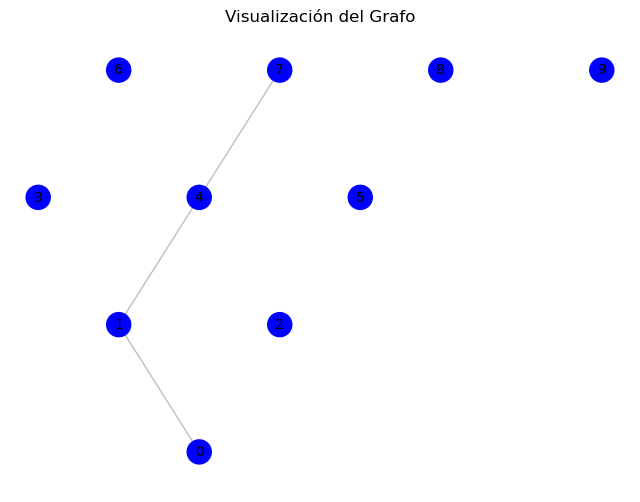

In [22]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def dibujar_grafo(data):
    # Convierte el grafo PyTorch Geometric a NetworkX
    G = to_networkx(data, edge_attrs=["edge_attr"], node_attrs=["x"], to_undirected=True)
    
    # Extrae posiciones de los nodos del atributo 'x' (coordenadas)
    pos = {i: (data.x[i, 0].item(), data.x[i, 1].item()) for i in range(data.num_nodes)}
    
    # Dibuja el grafo
    plt.figure(figsize=(8, 6))
    
    # Dibuja las aristas
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color="gray")
    
    # Dibuja los nodos (puedes cambiar colores según etiquetas o tiempo)
    node_colors = ["red" if t == 0 else "blue" for t in data.x[:, 2]]  # Rojo para nodos con tiempo=0
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)
    
    # Añade etiquetas a los nodos (índices)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")
    
    plt.title("Visualización del Grafo")
    plt.axis("off")
    plt.show()

# Llama a la función para dibujar el grafo
dibujar_grafo(grafo)



### Dataset

In [23]:
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data, Dataset

class GrafoDataset(Dataset):
    def __init__(self, data_rows, normalize=True):
        self.data_rows = data_rows
        self.normalize = normalize 

    def __len__(self):
        return len(self.data_rows)

    def __getitem__(self, idx):
        row = self.data_rows[idx]
        
        # Crear el grafo con posiciones
        data = crear_grafo_con_posiciones(row)
        
        # Normalizar las posiciones
        if self.normalize:
            data.x = self.normalizar_posiciones(data.x)
        
        if self.normalize and data.edge_attr is not None:
            data.edge_attr = self.normalizar_atributos(data.edge_attr)
        
        return data

    def normalizar_posiciones(self, x):
        # Usamos StandarScaler para normalizar las posiciones
        scaler = StandardScaler()
        pos = x.numpy()  # Convertir a numpy para usar el scaler
        pos_norm = scaler.fit_transform(pos)  
        return torch.tensor(pos_norm, dtype=torch.float)
    
    def normalizar_atributos(self, edge_attr):
        if edge_attr.numel() == 0:  # Si edge_attr está vacío
            #print("Warning: edge_attr vacío. No se normalizará.")
            return edge_attr  # Devuelve sin cambios
        # Usamos StandarScaler para normalizar las posiciones
        scaler = StandardScaler()
        attr = edge_attr.numpy()
        attr_norm = scaler.fit_transform(attr)
        return torch.tensor(attr_norm, dtype=torch.float)

# convertir a listas
df_segments_nodos_lista = df_segments_nodos.to_dict('records')
dataset = GrafoDataset(df_segments_nodos_lista)
print(f"Tamaño del dataset: {len(dataset)}")
ejemplo = dataset[15]
print('Ejemplo primer grafo:', ejemplo)
print('Numero de nodos:' , ejemplo.num_nodes)
print('Nodos:', ejemplo.x)
print('Numero de aristas:', ejemplo.num_edges)
print('Aristas:', ejemplo.edge_index)
print('atributos aristas:', ejemplo.edge_attr)

Tamaño del dataset: 18621
Ejemplo primer grafo: Data(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10])
Numero de nodos: 10
Nodos: tensor([[-4.0201e-01, -2.0000e+00,  1.1933e+00],
        [-9.0453e-01, -1.0000e+00,  1.2507e+00],
        [ 1.0050e-01, -1.0000e+00, -8.1562e-01],
        [-1.4071e+00, -4.1464e-08, -8.1562e-01],
        [-4.0201e-01, -4.1464e-08,  1.3243e+00],
        [ 6.0302e-01, -4.1464e-08, -8.1562e-01],
        [-9.0453e-01,  1.0000e+00, -8.1562e-01],
        [ 1.0050e-01,  1.0000e+00,  1.1255e+00],
        [ 1.1055e+00,  1.0000e+00, -8.1562e-01],
        [ 2.1106e+00,  1.0000e+00, -8.1562e-01]])
Numero de aristas: 3
Aristas: tensor([[0, 1, 4],
        [1, 4, 7]])
atributos aristas: tensor([[ 0.0000, -0.8317,  0.0000,  0.0000],
        [ 0.0000, -0.5747,  0.0000,  0.0000],
        [ 0.0000,  1.4064,  0.0000,  0.0000]])


### Graph Neural Network

In [24]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Dropout

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,dropout_prob=0.5 ):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = Dropout(p=dropout_prob) # añado el dropotu para desfavorecer el sobreajuste

    def forward(self, x, edge_index):
        # convolucion + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x  # Softmax logaritmico para clasificacion

# Usamos GPU pero si no esta disponible usamos CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')  # 'cuda' o 'cpu'

Device: cpu


### Train y tests dataset y dataloaders

In [25]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def filtrar(dataset):
    filtered_dataset = []
    for data in dataset:
        if data.x.size(0) > 0 and (data.edge_attr is None or data.edge_attr.size(0) > 0):
            filtered_dataset.append(data)
    return filtered_dataset

# Filtrar el dataset de entrenamiento y prueba
filtred_dataset = filtrar(dataset)
print(f'Tamaño del dataset despues del filtrado: {len(filtred_dataset)}')
# Dividimos el dataset
train_dataset, test_dataset = train_test_split(filtred_dataset, test_size=0.2, random_state=42)

# Comprobamos el tamaño
print(f'Tamaño de los datasets: train = {len(train_dataset)}, test = {len(test_dataset)}' )

Tamaño del dataset despues del filtrado: 17901
Tamaño de los datasets: train = 14320, test = 3581


In [26]:
#creo que estos nans vienen de los key que no tienen una coordenada asociada
# De momento vamos a filtrar los Nans y ya veremos de donde vienen
def filtrar_nans(dataset):
    filtered_dataset = []
    dataset_con_nans =[]
    for i , data in enumerate(dataset):
        if torch.isnan(data.x).sum() == 0 and torch.isnan(data.y).sum() == 0:
            filtered_dataset.append(data)
        else:
            dataset_con_nans.append(data)
            #print(f'Datos con nans: indice = {i}')
            #print('dato = {data} \n nodos: {data.x} \n aristas: {data.y}')
    return filtered_dataset, dataset_con_nans

train_dataset, dataset_nans_train = filtrar_nans(train_dataset)
test_dataset, dataset_nans_test = filtrar_nans(test_dataset)
# Comprobamos el tamaño
print(f'Tamaño de la parte del dataset con nans: train = {len(dataset_nans_train)}, test = {len(dataset_nans_test)}')
print(f'Tamaño de los datasets despues del fltrado: train = {len(train_dataset)}, test = {len(test_dataset)}' )

# Creamos DataLoaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Tamaño de la parte del dataset con nans: train = 733, test = 186
Tamaño de los datasets despues del fltrado: train = 13587, test = 3395


### Entrenamiento

Epoch 1/20, Train Loss: 0.2759, Validation Loss: 0.2572
Epoch 2/20, Train Loss: 0.2542, Validation Loss: 0.2506
Epoch 3/20, Train Loss: 0.2485, Validation Loss: 0.2459
Epoch 4/20, Train Loss: 0.2440, Validation Loss: 0.2417
Epoch 5/20, Train Loss: 0.2384, Validation Loss: 0.2341
Epoch 6/20, Train Loss: 0.2324, Validation Loss: 0.2286
Epoch 7/20, Train Loss: 0.2273, Validation Loss: 0.2255
Epoch 8/20, Train Loss: 0.2230, Validation Loss: 0.2218
Epoch 9/20, Train Loss: 0.2189, Validation Loss: 0.2179
Epoch 10/20, Train Loss: 0.2160, Validation Loss: 0.2128
Epoch 11/20, Train Loss: 0.2137, Validation Loss: 0.2192
Epoch 12/20, Train Loss: 0.2119, Validation Loss: 0.2086
Epoch 13/20, Train Loss: 0.2101, Validation Loss: 0.2108
Epoch 14/20, Train Loss: 0.2088, Validation Loss: 0.2049
Epoch 15/20, Train Loss: 0.2076, Validation Loss: 0.2090
Epoch 16/20, Train Loss: 0.2064, Validation Loss: 0.2110
Epoch 17/20, Train Loss: 0.2056, Validation Loss: 0.2038
Epoch 18/20, Train Loss: 0.2049, Validat

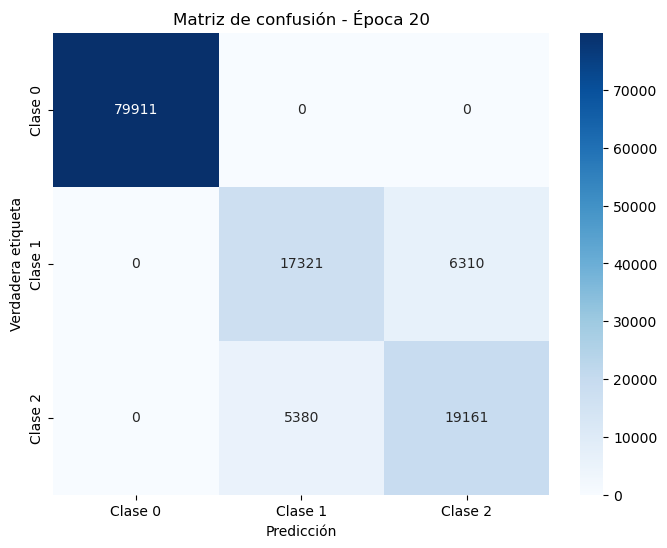

In [27]:
from torch.nn import CrossEntropyLoss
import torch
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
def confidence_score(num_nodes, confidence_gaps_probs, threshold):
    node_indices = list(range(num_nodes))
    # We'll create two subplots side-by-side:
    #   Left: The confidence gaps from the "logits then softmax" approach
    #   Right: The confidence gaps from the "direct probability" approach

    fig = plt.figure(figsize=(6,5))
    # --- PLOT for GCNProbabilities approach ---
    plt.bar(node_indices, confidence_gaps_probs, color='green', alpha=0.6)
    plt.axhline(threshold, color='red', linestyle='--', label='Grey zone threshold')
    plt.title("Confidence Gaps (Softmax in forward)")
    plt.xlabel("Node Index")
    plt.ylabel("Confidence Gap (Top1 - Top2)")
    plt.legend()

    plt.tight_layout()
    plt.show()

    
def plot_confusion(all_preds, all_labels, epoch):
    # Matriz 
    cm = confusion_matrix(all_labels, all_preds)
    
    # El classification report tiene 3 clases. Clase 1: izq, Clase 2: der, clase 0: no pertenece al segmento
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1", "Clase 2"]))
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1", "Clase 2"], yticklabels=["Clase 0", "Clase 1", "Clase 2"])
    plt.xlabel('Predicción')
    plt.ylabel('Verdadera etiqueta')
    plt.title(f'Matriz de confusión - Época {epoch + 1}')
    plt.show()

# Parametros
input_dim = 3   # x, y, tiempo
hidden_dim = 15
output_dim = 3  # Numero de clases (izq, der, no pertence al segmento)

# We'll define a threshold below which we consider the prediction to be
# in a "grey zone" (high uncertainty).
threshold = 0.1

# modelo, optimizador y perdida
model = GCN(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = CrossEntropyLoss()

# epocas
epochs = 20

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Hago una lista para guardar los datos con confidence score<threshold
below_threshold_data = []
# entrenamiento
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas
    num_ambiguo = 0
    no_ambiguio = 0
    for data in train_loader:
        # Verificar si el grafo tiene aristas, si no las tiene continuamos puesto q no forma segmento
        if data.edge_index.numel() == 0:  
            continue 

        optimizer.zero_grad()
        
        # Forward pass
        out = model(data.x, data.edge_index)

        # Calcular perdida
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Obtener predicciones y etiquetas verdaderas
        preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
        labels = data.y.cpu().numpy()  # Etiquetas verdaderas

        # Añadilos las predicciones y etiquetas a sus listas
        all_preds.extend(preds)
        all_labels.extend(labels)

        # CONFIDENCE SCORE en la ultima epoca
        if epoch == epochs-1:
            with torch.no_grad():
                probabilities_direct_model = model(data.x, data.edge_index)

            confidence_gaps_probs = []  

            for node_idx, prob_vec in enumerate(probabilities_direct_model):
                top2_probs, top2_classes = torch.topk(prob_vec, 2) # Get top-2 classes
                confidence_gap = top2_probs[0] - top2_probs[1] # Compute confidence gap
                confidence_gaps_probs.append(confidence_gap.item()) # Record gap
                
                if confidence_gap < threshold:
                    num_ambiguo += 1
                    
                    below_threshold_data.append({
                        'data': data,
                        'node_idx': node_idx,
                        'prob_vec': prob_vec,
                        'confidence_gap': confidence_gap
                    })

                else:
                    no_ambiguio += 1


    # Añadimos perdidas y exactitudes a sus listas
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds, average='macro')) #average = macro porque ahora tenemos 3 clases (ya no es binario)

    # Evaluar modelo
    model.eval()
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    
    with torch.no_grad():
        # Procedimiento analoco al del entrenamiento
        for data in test_loader:
            if data.edge_index.numel() == 0:  
                continue 

            data = data.to(device)
            logits = model(data.x, data.edge_index)
            loss = loss_fn(logits, data.y)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)

            # Guardamos predicciones y eqtiquetas
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())

    # Guardamos perdidas, exactitudes...
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_losses.append(val_loss/len(test_loader))
    val_accuracies.append(f1_score(all_labels_val, all_preds_val, average='macro'))

    # Imprimimos resumtados por epoca
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(test_loader):.4f}")

    # Plot de la matriz de confusion cada 5 epocas para ver si el modelo mejora
    if (epoch+1) == epochs:
        plot_confusion(all_preds, all_labels, epoch)


Numero de datos no ambiguos:122690, numero de datos ambiguos:5393


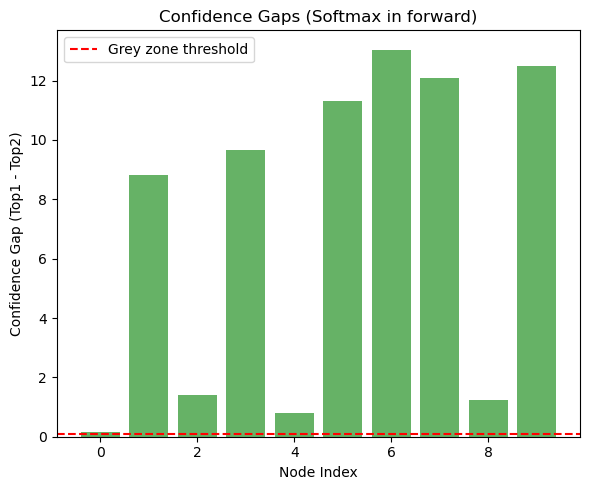

[DataBatch(x=[10, 3], edge_index=[2, 1], edge_attr=[1, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 1], edge_attr=[1, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 2], edge_attr=[2, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 2], edge_attr=[2, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 3], edge_attr=[3, 4], y=[10], ptr=[2]), DataBatch(x=[10, 3], edge_index=[2, 2], edge_attr=[2, 4], y=[10], ptr=[2]), DataBatch(x

In [ ]:
print(f'Numero de datos no ambiguos:{no_ambiguio}, numero de datos ambiguos:{num_ambiguo}')
num_nodes = len(probabilities_direct_model)
confidence_score(num_nodes, confidence_gaps_probs, threshold)

# Nueva lista para almacenar grafos duplicados
augmented_data = []

for dato in below_threshold_data:
    original = dato['data']
    node_idx = dato['node_idx']

    # copias del grafo original
    izquierda = original.clone()
    derecha = original.clone()
 
    # añadir dos etiquetas
    izquierda.y[node_idx] = 1  # Izquierda
    derecha.y[node_idx] = 2  # Derecha

    # Agregar los nuevos grafos a la lista
    augmented_data.append(izquierda)
    augmented_data.append(derecha)
    
for data in augmented_data:
    if hasattr(data, 'batch'):
        del data.batch  # Elimino batch porque me esta dando problemas


print(augmented_data)

train_dataset = train_dataset + augmented_data  # juntar los datasets
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
print(len(train_loader))

In [29]:
ejemplo = augmented_data[2]
print(ejemplo.x, ejemplo.edge_index, ejemplo.y)

tensor([[-4.0201e-01, -2.0000e+00,  1.7532e+00],
        [-9.0454e-01, -1.0000e+00,  1.4732e+00],
        [ 1.0050e-01, -1.0000e+00, -6.5168e-01],
        [-1.4071e+00, -4.1464e-08,  1.3353e+00],
        [-4.0201e-01, -4.1464e-08, -6.5168e-01],
        [ 6.0302e-01, -4.1464e-08, -6.5168e-01],
        [-9.0454e-01,  1.0000e+00, -6.5168e-01],
        [ 1.0050e-01,  1.0000e+00, -6.5168e-01],
        [ 1.1055e+00,  1.0000e+00, -6.5168e-01],
        [ 2.1106e+00,  1.0000e+00, -6.5168e-01]]) tensor([[0, 1],
        [1, 3]]) tensor([1, 2, 0, 1, 0, 0, 0, 0, 0, 0])


Epoch 1/20, Train Loss: 0.2668, Validation Loss: 0.2603
Epoch 2/20, Train Loss: 0.2550, Validation Loss: 0.2502
Epoch 3/20, Train Loss: 0.2442, Validation Loss: 0.2393
Epoch 4/20, Train Loss: 0.2338, Validation Loss: 0.2310
Epoch 5/20, Train Loss: 0.2255, Validation Loss: 0.2220
Epoch 6/20, Train Loss: 0.2193, Validation Loss: 0.2178
Epoch 7/20, Train Loss: 0.2146, Validation Loss: 0.2179
Epoch 8/20, Train Loss: 0.2107, Validation Loss: 0.2099
Epoch 9/20, Train Loss: 0.2069, Validation Loss: 0.2079
Epoch 10/20, Train Loss: 0.2030, Validation Loss: 0.2039
Epoch 11/20, Train Loss: 0.1996, Validation Loss: 0.1978
Epoch 12/20, Train Loss: 0.1971, Validation Loss: 0.1951
Epoch 13/20, Train Loss: 0.1949, Validation Loss: 0.1932
Epoch 14/20, Train Loss: 0.1931, Validation Loss: 0.1919
Epoch 15/20, Train Loss: 0.1918, Validation Loss: 0.1888
Epoch 16/20, Train Loss: 0.1907, Validation Loss: 0.1914
Epoch 17/20, Train Loss: 0.1900, Validation Loss: 0.1916
Epoch 18/20, Train Loss: 0.1891, Validat

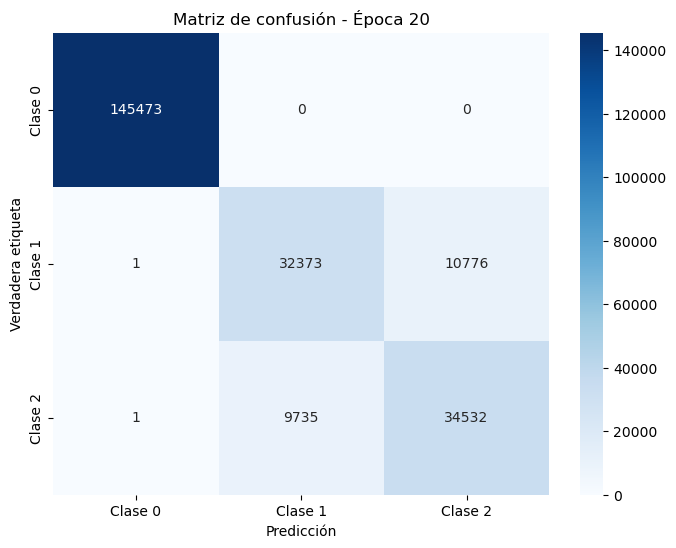

Numero de grafos ambiguos = 7255


In [30]:
class GCN_2(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,dropout_prob=0.5 ):
        super(GCN_2, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = Dropout(p=dropout_prob) # añado el dropotu para desfavorecer el sobreajuste

    def forward(self, x, edge_index):
        # convolucion + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x  # Softmax logaritmico para clasificacion


# Parametros
input_dim = 3   # x, y, tiempo
hidden_dim = 15
output_dim = 3  # Numero de clases (izq, der, no pertence al segmento)

# We'll define a threshold below which we consider the prediction to be
# in a "grey zone" (high uncertainty).
threshold = 0.1

# modelo, optimizador y perdida
model = GCN_2(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = CrossEntropyLoss()

# epocas
epochs = 20

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Hago una lista para guardar los datos con confidence score<threshold
below_threshold_data = []
# entrenamiento
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas
    num_ambiguo = 0
    no_ambiguio = 0
    for data in train_loader:
        # Verificar si el grafo tiene aristas, si no las tiene continuamos puesto q no forma segmento
        if data.edge_index.numel() == 0:  
            continue 

        optimizer.zero_grad()
        
        # Forward pass
        out = model(data.x, data.edge_index)

        # Calcular perdida
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Obtener predicciones y etiquetas verdaderas
        preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
        labels = data.y.cpu().numpy()  # Etiquetas verdaderas

        # Añadilos las predicciones y etiquetas a sus listas
        all_preds.extend(preds)
        all_labels.extend(labels)

        # CONFIDENCE SCORE en la ultima epoca
        if epoch == epochs-1:
            with torch.no_grad():
                probabilities_direct_model = model(data.x, data.edge_index)

            confidence_gaps_probs = []  

            #print("=== Direct Probability Model Output (Softmax in forward) ===")
            for node_idx, prob_vec in enumerate(probabilities_direct_model):
                top2_probs, top2_classes = torch.topk(prob_vec, 2) # Get top-2 classes
                confidence_gap = top2_probs[0] - top2_probs[1] # Compute confidence gap
                confidence_gaps_probs.append(confidence_gap.item()) # Record gap
                
                if confidence_gap < threshold:
                    num_ambiguo += 1
                    
                    below_threshold_data.append({
                        'data': data,
                        'node_idx': node_idx,
                        'prob_vec': prob_vec,
                        'confidence_gap': confidence_gap
                    })

                else:
                    no_ambiguio += 1


    # Añadimos perdidas y exactitudes a sus listas
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds, average='macro')) #average = macro porque ahora tenemos 3 clases (ya no es binario)

    # Evaluar modelo
    model.eval()
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    
    with torch.no_grad():
        # Procedimiento analoco al del entrenamiento
        for data in test_loader:
            if data.edge_index.numel() == 0:  
                continue 

            data = data.to(device)
            logits = model(data.x, data.edge_index)
            loss = loss_fn(logits, data.y)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)

            # Guardamos predicciones y eqtiquetas
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())

    # Guardamos perdidas, exactitudes...
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_losses.append(val_loss/len(test_loader))
    val_accuracies.append(f1_score(all_labels_val, all_preds_val, average='macro'))

    # Imprimimos resumtados por epoca
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(test_loader):.4f}")

    # Plot de la matriz de confusion cada 5 epocas para ver si el modelo mejora
    if (epoch+1) == epochs:
        plot_confusion(all_preds, all_labels, epoch)
        print(f'Numero de grafos ambiguos = {len(below_threshold_data)}')


### Curvas aprendizaje

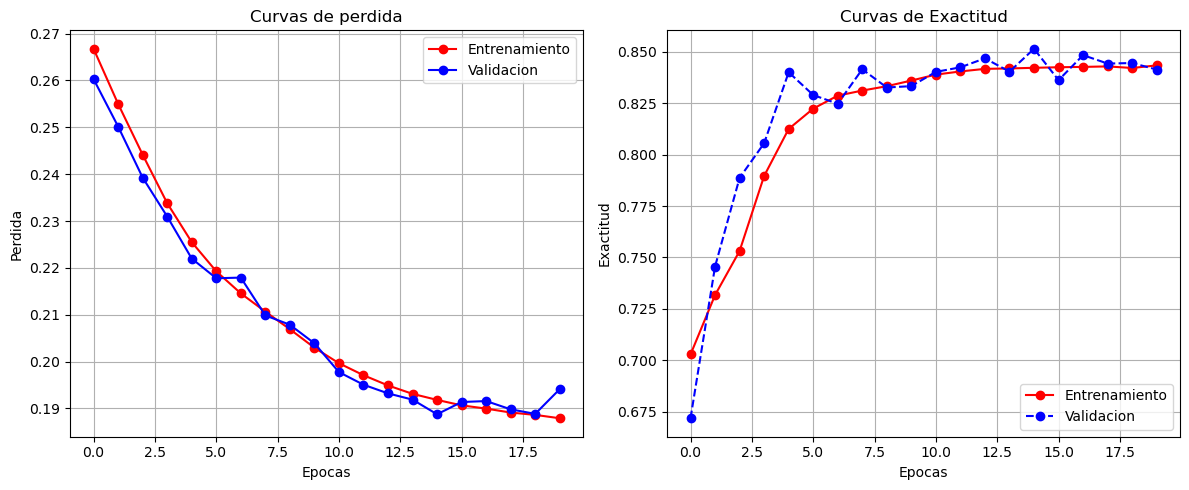

In [31]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(train_losses, 'o-', color='red',label='Entrenamiento')
ax[0].plot(val_losses, 'o-', color='blue',label='Validacion')
ax[0].set_xlabel('Epocas')
ax[0].set_ylabel('Perdida')
ax[0].set_title('Curvas de perdida')
ax[0].grid()
ax[0].legend()

ax[1].plot(train_accuracies, 'o-', color='red', label = 'Entrenamiento')
ax[1].plot(val_accuracies, 'o--', color='blue',label = 'Validacion')
ax[1].set_xlabel('Epocas')
ax[1].set_ylabel('Exactitud')
ax[1].set_title('Curvas de Exactitud')
ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()

(array([145475.,      0.,      0.,      0.,      0.,  42108.,      0.,
             0.,      0.,  45308.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

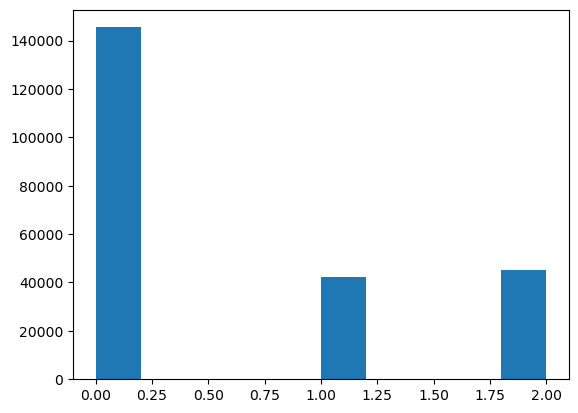

In [32]:
plt.hist(all_preds)

### Ver datos 

In [33]:
# Visualizar un lote de datos para ver que esta pasando
def ver_datos(dataloader, n=1):
    #n es el numero de grafos que quieres ver
    for i, data in enumerate(dataloader):
        print(f"Batch {i + 1}:")
        print(f"x (nodos): {data.x.shape}")
        print(f"edge_index (aristas): {data.edge_index.shape}")
        print(f"data.y.shape: {data.y.shape}")
        print(f"data.y.numpy: {data.y.numpy()}")
        
        # Imprimir nodos, aristas y atributos
        print(f"Nodos: {data.x[:]}")
        print(f"aristas: {data.edge_index[:, :]}")
        print(f" etiquetas de aristas: {data.y[:]}")
        
        if i == n:
            break
# recuerda q aparecen 20 nodos porque el batchsize es 2, entonces ha concatenado 2 grafos
ver_datos(train_loader)

Batch 1:
x (nodos): torch.Size([10, 3])
edge_index (aristas): torch.Size([2, 3])
data.y.shape: torch.Size([10])
data.y.numpy: [2 1 0 0 2 0 0 1 0 0]
Nodos: tensor([[-4.0202e-01, -2.0000e+00,  1.1103e+00],
        [-9.0453e-01, -1.0000e+00,  1.3297e+00],
        [ 1.0050e-01, -1.0000e+00, -8.1450e-01],
        [-1.4071e+00, -4.1464e-08, -8.1450e-01],
        [-4.0202e-01, -4.1464e-08,  1.1120e+00],
        [ 6.0302e-01, -4.1464e-08, -8.1450e-01],
        [-9.0453e-01,  1.0000e+00, -8.1450e-01],
        [ 1.0050e-01,  1.0000e+00,  1.3350e+00],
        [ 1.1055e+00,  1.0000e+00, -8.1450e-01],
        [ 2.1106e+00,  1.0000e+00, -8.1450e-01]])
aristas: tensor([[0, 1, 4],
        [1, 4, 7]])
 etiquetas de aristas: tensor([2, 1, 0, 0, 2, 0, 0, 1, 0, 0])
Batch 2:
x (nodos): torch.Size([10, 3])
edge_index (aristas): torch.Size([2, 3])
data.y.shape: torch.Size([10])
data.y.numpy: [1 0 2 0 1 0 0 0 2 0]
Nodos: tensor([[-4.0202e-01, -2.0000e+00,  1.1142e+00],
        [-9.0454e-01, -1.0000e+00, -8.15

### Validacion

              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00     19789
     Clase 1       0.90      0.60      0.72      5913
     Clase 2       0.71      0.93      0.80      6081

    accuracy                           0.91     31783
   macro avg       0.87      0.84      0.84     31783
weighted avg       0.93      0.91      0.91     31783



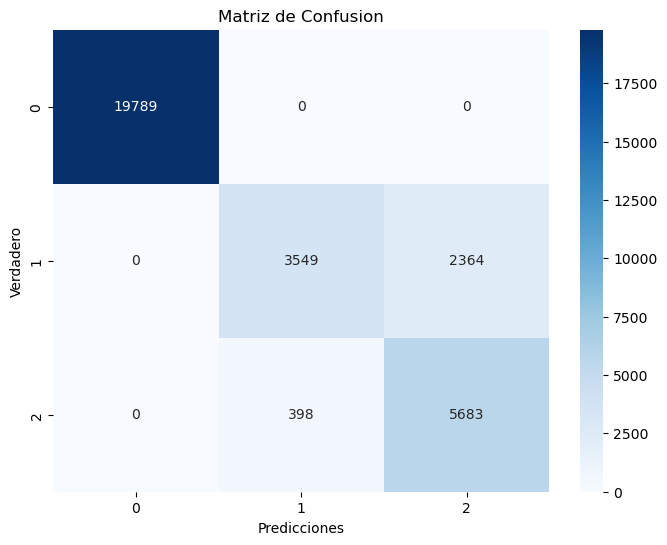

In [34]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Desactivar gradientes
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())
    
    # Concatenar predicciones y etiquetas reales
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    # Calcular matriz de confusion y el report
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1", "Clase 2"]))
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

evaluar_modelo(model, test_loader, device)


### ROC y AUC

In [35]:
import torch
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Funcion para almacenar probabilidades y etiquetas
def probs_labels(model, data_loader, device):

    # Almacenamos probabilidades y etiquetas
    all_probs = []  
    all_labels = []  

    model.eval()
    with torch.no_grad():
        for data in data_loader:
            # Mismo procedimiento que anteriormente
            if data.edge_index.numel() == 0:  
                continue 
            data = data.to(device)
            out = model(data.x, data.edge_index)
            probs = torch.nn.functional.softmax(out, dim=1)  # Ahora se almacenan las probabilidades en lugar de las predicciones

            # Guardamos probabilidades y etiquetan
            all_probs.append(probs.cpu().numpy())  
            all_labels.append(data.y.cpu().numpy())

    # Concatenamos despues de cada bucle
    all_probs = np.concatenate(all_probs, axis=0)  
    all_labels = np.concatenate(all_labels, axis=0)  
    return all_probs, all_labels


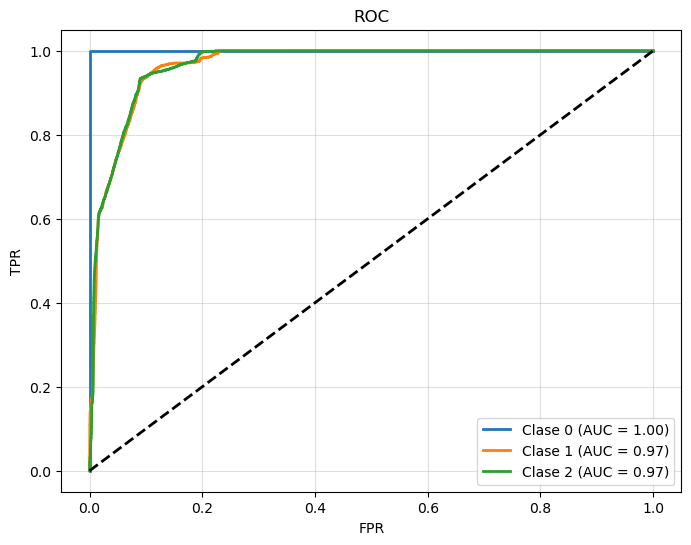

In [36]:
def plot_roc(all_probs, all_labels, num_classes=3):
    # Para guardar los elementos de las curvas ROC
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Bucle para calcular las ROC para cada clase en este caso tenemos tres clases
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels == i, all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot
    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle='--')
    plt.grid(alpha = 0.4)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC')
    plt.legend()
    plt.show()
    
all_probs, all_labels = probs_labels(model, test_loader, device)
plot_roc(all_probs, all_labels, num_classes=3)  # tenemos tras clases

### Curva precision recall

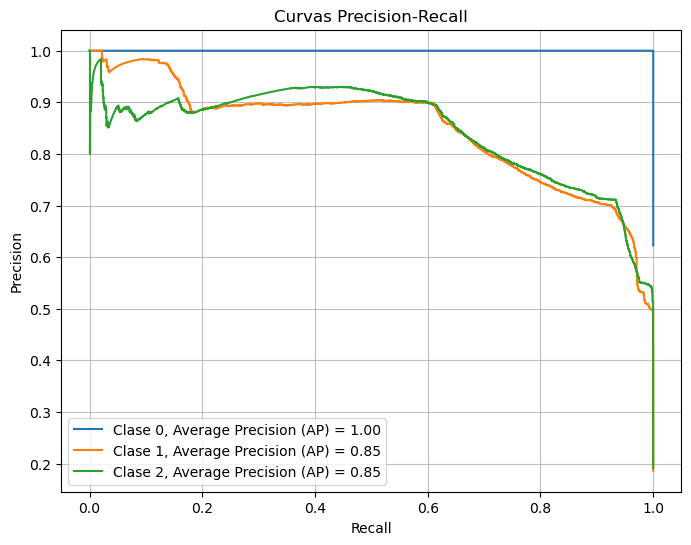

In [37]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_precision_recall(all_probs, all_labels, num_classes):
    plt.figure(figsize=(8,6))
    
    for class_idx in range(num_classes):
        # Para cada clase se necesita cambiar las etiquetas a binario para poder calcular la precission recall
        true_binary = (all_labels == class_idx).astype(int)
        
        # caculamos parametros
        precision, recall, _ = precision_recall_curve(true_binary, all_probs[:, class_idx])
        pr_auc = auc(recall, precision)
        
        # plot
        plt.plot(recall, precision, label=f'Clase {class_idx}, Average Precision (AP) = {pr_auc:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall')
    plt.legend()
    plt.grid(alpha=0.8)
    plt.show()

num_classes = 3 # tenemos tres clases
plot_precision_recall(all_probs, all_labels, num_classes)